# Physics-Informed Continuous Muscle-Fatigue Estimation from Measured sEMG

This notebook uses both supplied datasets: the 13-subject self-perceived-fatigue (SPF)
labels and the complete 13-subject measured sEMG/MVC corpus. It contains no label-derived signal
synthesis and regenerates every reported result from quality-controlled measured recordings.

In [1]:
# Reproducible setup
import os, re, glob, json, time, math, warnings, zipfile
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn
import torch.nn.functional as Fnn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# "quick" checks the entire pipeline with two trials/subject. "full" reports final results.
RUN_MODE = "full"
if RUN_MODE == "quick":
    TRIALS_PER_SUBJECT, FINAL_EPOCHS, SEARCH_EPOCHS = 2, 5, 4
else:
    TRIALS_PER_SUBJECT, FINAL_EPOCHS, SEARCH_EPOCHS = None, 12, 6

WIN, STEP = 512, 128                 # proposal values
MODEL_SUBSAMPLE = 8                  # model cadence ~=0.81 s at 1259 Hz
CHUNK_LEN = 96
MIN_DURATION_COVERAGE = 0.80
F_DEFAULT, R_DEFAULT = 0.0113, 0.0019

CACHE_VERSION = "complete13_biceps_mvc_w512_s128_v1"
RESULTS_VERSION = "raw_tcn_gru_hybrid13_v1"
CACHE_DIR = os.path.join("pipeline_cache", CACHE_VERSION)
RESULTS_DIR = os.path.join("results_cache", RESULTS_VERSION)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"RUN_MODE={RUN_MODE}; final epochs={FINAL_EPOCHS}; cache={CACHE_VERSION}")

Device: cpu
RUN_MODE=full; final epochs=12; cache=complete13_biceps_mvc_w512_s128_v1


## 1. Audit and pair the SPF and complete sEMG datasets

The new sEMG folder has one extra nested subject directory. Discovery is recursive, so the same
code works locally and after extracting the subject archives in Colab. Trial IDs now correspond
directly to SPF trial IDs; no acquisition-order remapping is used.

In [2]:
def subject_num(path):
    m = re.search(r"subject_(\d+)", path, re.IGNORECASE)
    return int(m.group(1)) if m else -1

def trial_num(path):
    m = re.search(r"trial_(\d+)\.csv$", os.path.basename(path), re.IGNORECASE)
    return int(m.group(1)) if m else -1

def find_spf_root():
    candidates = glob.glob(os.path.join("**", "self_perceived_fatigue_index"), recursive=True)
    for root in sorted(set(candidates), key=len):
        if glob.glob(os.path.join(root, "subject_*", "*.csv")):
            return root
    raise FileNotFoundError("Could not find SPF subject folders")

def find_semg_root():
    candidates = ["sEMG_data"] + glob.glob(os.path.join("**", "sEMG_data"), recursive=True)
    for root in sorted(set(candidates), key=len):
        if os.path.isdir(root) and glob.glob(os.path.join(root, "**", "trial_*.csv"), recursive=True):
            return root
    raise FileNotFoundError("Could not find the complete sEMG_data folder")

def last_positive_timestamp(path, tail_bytes=32768):
    with open(path, "rb") as fh:
        fh.seek(0, os.SEEK_END); size = fh.tell()
        fh.seek(max(0, size-tail_bytes))
        lines = fh.read().decode("utf-8", errors="ignore").splitlines()
    if size > tail_bytes: lines = lines[1:]
    values = []
    for line in lines:
        try:
            value = float(line.split(",",1)[0])
            if 0 < value < 10000: values.append(value)
        except (ValueError, IndexError):
            pass
    if not values: raise ValueError(f"No final timestamp recovered from {path}")
    return max(values)

def raw_emg_columns(path):
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    return [c for c in cols if "[V]" in c and "filter" not in c.lower()]

SPF_DIR, SEMG_DIR = find_spf_root(), find_semg_root()
spf_files = sorted(glob.glob(os.path.join(SPF_DIR, "subject_*", "*.csv")),
                   key=lambda p:(subject_num(p),trial_num(p)))
semg_files = sorted(glob.glob(os.path.join(SEMG_DIR, "**", "trial_*.csv"), recursive=True),
                    key=lambda p:(subject_num(p),trial_num(p)))
mvc_files = sorted(glob.glob(os.path.join(SEMG_DIR, "**", "MVC", "*.csv"), recursive=True))
spf_lookup = {(subject_num(p),trial_num(p)):p for p in spf_files}
semg_lookup = {(subject_num(p),trial_num(p)):p for p in semg_files}

print("SPF root:", SPF_DIR)
print("sEMG root:", SEMG_DIR)
print(f"SPF={len(spf_lookup)} files; sEMG trials={len(semg_lookup)}; MVC={len(mvc_files)}")
assert len(spf_lookup)==156 and len(semg_lookup)==156 and len(mvc_files)==104

# All eight MVC files are audited; the two biceps files/subject are used by proposal scope.
mvc_lookup = {}
for path in mvc_files:
    name = os.path.basename(path).upper()
    if "BICEPS" in name:
        side = "L" if "_L_BICEPS" in name else "R"
        mvc_lookup[(subject_num(path),side)] = path
assert len(mvc_lookup)==26

rows, excluded = [], []
for key, semg_path in semg_lookup.items():
    subject, trial = key
    spf_path = spf_lookup.get(key)
    raw_cols = raw_emg_columns(semg_path)
    biceps = [c for c in raw_cols if "BICEPS" in c.upper()]
    side = "R" if trial%2 else "L"
    semg_duration = last_positive_timestamp(semg_path)
    spf_duration = float(pd.read_csv(spf_path,usecols=["time"])["time"].iloc[-1])
    coverage = semg_duration/spf_duration
    row = dict(key=f"s{subject:02d}_t{trial:02d}",subject=subject,trial=trial,side=side,
               semg_file=semg_path,spf_file=spf_path,mvc_file=mvc_lookup[(subject,side)],
               semg_duration=semg_duration,spf_duration=spf_duration,coverage=coverage,
               n_raw_channels=len(raw_cols),biceps_column=biceps[0] if len(biceps)==1 else None)
    if len(raw_cols)!=4 or len(biceps)!=1:
        excluded.append(dict(subject=subject,trial=trial,reason="invalid four-channel/biceps schema"))
    elif coverage<MIN_DURATION_COVERAGE:
        excluded.append(dict(subject=subject,trial=trial,
                             reason=f"truncated: duration coverage={coverage:.1%}"))
    else:
        rows.append(row)

pair_manifest = pd.DataFrame(rows).sort_values(["subject","trial"]).reset_index(drop=True)
excluded_table = pd.DataFrame(excluded).sort_values(["subject","trial"]).reset_index(drop=True)
RECORDS = {r["key"]:r for r in pair_manifest.to_dict("records")}

print(f"Quality-controlled pairs: {len(pair_manifest)}/156")
print(pair_manifest.groupby("subject").size().rename("usable_trials").to_string())
print("\nExcluded recordings:")
display(excluded_table)
assert len(pair_manifest)==150 and pair_manifest.subject.nunique()==13
assert pair_manifest.coverage.median()>0.98

label_monotone = []
for path in spf_files:
    y = pd.read_csv(path,usecols=["label"])["label"].to_numpy()
    label_monotone.append(bool(np.all(np.diff(y)>=0)))
assert all(label_monotone)
print(f"Non-decreasing SPF labels: {sum(label_monotone)}/{len(label_monotone)}")

SPF root: self_perceived_fatigue_index\self_perceived_fatigue_index
sEMG root: sEMG_data
SPF=156 files; sEMG trials=156; MVC=104
Quality-controlled pairs: 150/156
subject
1     12
2     12
3     12
4     12
5     12
6     11
7     12
8     10
9     11
10    12
11    12
12    11
13    11

Excluded recordings:


,subject,trial,reason
0,6,5,truncated: duration coverage=6.5%
1,8,4,truncated: duration coverage=44.2%
2,8,12,truncated: duration coverage=69.3%
3,9,11,truncated: duration coverage=68.5%
4,12,3,truncated: duration coverage=18.9%
5,13,12,truncated: duration coverage=68.4%


Non-decreasing SPF labels: 156/156


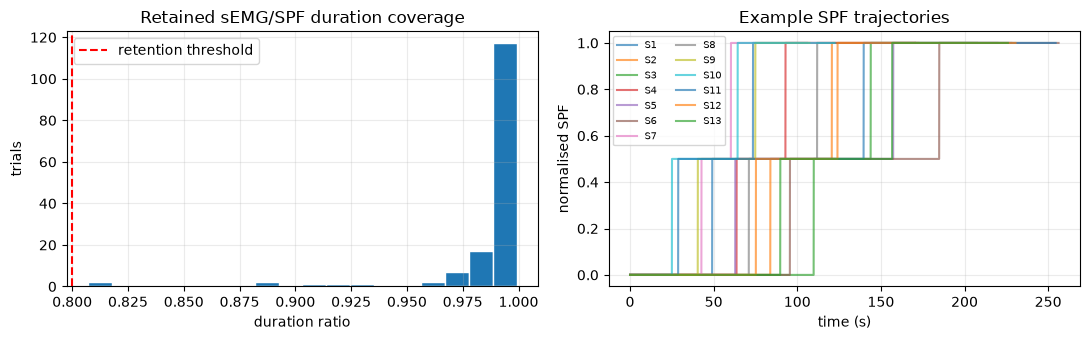

In [3]:
fig, axes = plt.subplots(1,2,figsize=(11,3.5))
axes[0].hist(pair_manifest.coverage,bins=18,edgecolor="white")
axes[0].axvline(MIN_DURATION_COVERAGE,color="red",ls="--",label="retention threshold")
axes[0].set(title="Retained sEMG/SPF duration coverage",xlabel="duration ratio",ylabel="trials")
for subject,row in pair_manifest.groupby("subject").first().iterrows():
    d=pd.read_csv(row.spf_file)
    axes[1].plot(d.time,d.label/2,alpha=.65,label=f"S{subject}")
axes[1].set(title="Example SPF trajectories",xlabel="time (s)",ylabel="normalised SPF")
axes[1].legend(ncol=2,fontsize=7)
for ax in axes: ax.grid(alpha=.25)
axes[0].legend(); plt.tight_layout(); plt.show()

## 2. Phase 1 — biceps sEMG preprocessing, MVC normalisation, RMS and MDF

Odd-numbered trials contain right-side channels and even-numbered trials left-side channels. The
corresponding biceps channel is filtered and divided by that subject/side's robust MVC reference
(95th percentile of window RMS in the biceps MVC recording). This supplies the %MVC-like load
required by 3CCr without using SPF labels or test-subject calibration.

At the detected trial sampling rate (~1259 Hz), 512 samples are ~407 ms and a 128-sample step is
~102 ms. The proposal's phrase “80 ms windows” is therefore numerically inaccurate; its explicit
512/128 sample settings are used.

In [4]:
def read_biceps_signal(path):
    header = pd.read_csv(path,nrows=0).columns.tolist()
    raw = [c for c in header if "[V]" in c and "filter" not in c.lower() and "BICEPS" in c.upper()]
    if len(raw)!=1: raise ValueError(f"Expected one raw biceps channel in {path}; found {raw}")
    signal_col = raw[0]; idx = header.index(signal_col); time_col = header[idx-1]
    d = pd.read_csv(path,usecols=[time_col,signal_col],dtype=np.float32)
    t = d[time_col].to_numpy(dtype=np.float64)
    x = d[signal_col].to_numpy(dtype=np.float32)
    valid = np.isfinite(t)&np.isfinite(x); t,x=t[valid],x[valid]
    drops=np.flatnonzero(np.diff(t)<=0)
    if len(drops): t,x=t[:drops[0]+1],x[:drops[0]+1]
    fs=float(1/np.median(np.diff(t)))
    return t,x,fs,signal_col

def bandpass(sig,fs,lo=20.0,hi=450.0,order=4):
    hi=min(hi,.95*fs/2)
    sos=butter(order,[lo/(fs/2),hi/(fs/2)],btype="bandpass",output="sos")
    return sosfiltfilt(sos,sig).astype(np.float32)

def window_view(sig,win=WIN,step=STEP):
    if len(sig)<win: raise ValueError("Signal shorter than one analysis window")
    return np.lib.stride_tricks.sliding_window_view(sig,win)[::step]

def rms_windows(sig,win=WIN,step=STEP):
    w=window_view(sig,win,step)
    return np.sqrt(np.mean(w.astype(np.float64)**2,axis=1)).astype(np.float32)

def feature_windows(sig,fs,win=WIN,step=STEP):
    w=window_view(sig,win,step)
    rms=np.sqrt(np.mean(w.astype(np.float64)**2,axis=1)).astype(np.float32)
    freq,pxx=welch(w,fs=fs,nperseg=win,axis=1)
    csum=np.cumsum(pxx,axis=1)
    idx=np.argmax(csum>=csum[:,-1,None]/2,axis=1)
    mdf=freq[idx].astype(np.float32)
    starts=np.arange(len(w))*step
    centers=((starts+win/2)/fs).astype(np.float32)
    return centers,rms,mdf,w

# Signal-processing unit tests required by the proposal.
FS_TEST=1259.0
t_test=np.arange(0,2,1/FS_TEST)
x_test=np.sin(2*np.pi*5*t_test)+np.sin(2*np.pi*200*t_test)+np.sin(2*np.pi*550*t_test)
y_test=bandpass(x_test,FS_TEST)
def band_power(x,f0,f1,fs):
    f,p=welch(x,fs=fs,nperseg=min(1024,len(x)))
    return p[(f>=f0)&(f<=f1)].sum()
p_before=band_power(x_test,0,20,FS_TEST)+band_power(x_test,450,FS_TEST/2,FS_TEST)
p_after=band_power(y_test,0,20,FS_TEST)+band_power(y_test,450,FS_TEST/2,FS_TEST)
atten_db=10*np.log10((p_before+1e-12)/(p_after+1e-12))
tone=np.sin(2*np.pi*100*np.arange(WIN)/FS_TEST).astype(np.float32)
_,_,tone_mdf,_=feature_windows(tone,FS_TEST,WIN,WIN)
mdf_err=abs(float(tone_mdf[0])-100)
print(f"Bandpass attenuation={atten_db:.1f} dB ({'PASS' if atten_db>=40 else 'FAIL'})")
print(f"100-Hz MDF error={mdf_err:.2f} Hz ({'PASS' if mdf_err<=2 else 'FAIL'})")

Bandpass attenuation=57.3 dB (PASS)
100-Hz MDF error=0.82 Hz (PASS)


In [5]:
# Compute/load subject- and side-specific biceps MVC references.
mvc_cache=os.path.join(CACHE_DIR,"mvc_references.json")
if os.path.exists(mvc_cache):
    with open(mvc_cache) as fh: mvc_references=json.load(fh)
else:
    mvc_references={}
    for (subject,side),path in sorted(mvc_lookup.items()):
        _,sig,fs,_=read_biceps_signal(path)
        rms=rms_windows(bandpass(sig,fs))
        positive=rms[rms>0]
        ref=float(np.percentile(positive,95))
        if not np.isfinite(ref) or ref<=0: raise ValueError(f"Invalid MVC reference for S{subject}{side}")
        mvc_references[f"{subject}_{side}"]=ref
    with open(mvc_cache,"w") as fh: json.dump(mvc_references,fh,indent=2)

mvc_table=pd.DataFrame([dict(subject=int(k.split('_')[0]),side=k.split('_')[1],mvc_rms_v=v)
                        for k,v in mvc_references.items()]).sort_values(["subject","side"])
display(mvc_table.pivot(index="subject",columns="side",values="mvc_rms_v").round(6))
assert len(mvc_references)==26 and min(mvc_references.values())>0

side,L,R
subject,,
1,0.000169,0.000324
2,0.000248,0.000278
3,0.000468,0.000616
4,0.000430,0.000410
5,0.000256,0.000560
6,0.001011,0.001359
7,0.000767,0.000763
8,0.000748,0.001516
9,0.000558,0.000722


## 3. Phase 2 — activation-driven Three-Compartment Fatigue Model (3CCr)

The model tracks active ($M_A$), fatigued ($M_F$), and resting ($M_R$) motor-unit fractions. The
target load is the smoothed biceps RMS/MVC trajectory, rather than the same constant curve for every
trial. Literature values $F=0.0113$ and $R=0.0019$ initialise the forward model. Euler integration
uses substeps for numerical stability while retaining the proposal's forward-Euler formulation.

3CCr conservation error=1.19e-07
MF non-decreasing under constant load: True


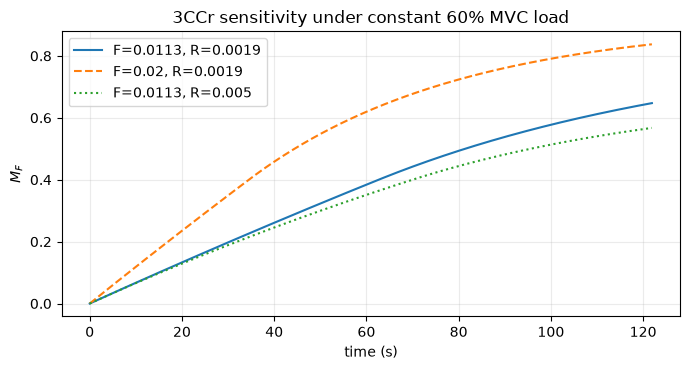

In [6]:
def simulate_3ccr(load,dt,fatigue_rate=F_DEFAULT,recovery_rate=R_DEFAULT,
                  develop_rate=10.0,relax_rate=10.0,substeps=5):
    load=np.clip(np.asarray(load,dtype=float),0,1); n=len(load)
    MA,MF,MR=np.empty(n),np.empty(n),np.empty(n)
    MA[0],MF[0],MR[0]=load[0],0.0,1-load[0]
    h=dt/substeps
    for i in range(1,n):
        ma,mf,mr=MA[i-1],MF[i-1],MR[i-1]; target=load[i-1]
        for _ in range(substeps):
            command=min(develop_rate*(target-ma),relax_rate*mr) if ma<target else develop_rate*(target-ma)
            mr += h*(-command+recovery_rate*mf)
            ma += h*(command-fatigue_rate*ma)
            mf += h*(fatigue_rate*ma-recovery_rate*mf)
            state=np.clip(np.array([ma,mf,mr]),0,None); state/=state.sum()+1e-12
            ma,mf,mr=state
        MA[i],MF[i],MR[i]=ma,mf,mr
    return MA.astype(np.float32),MF.astype(np.float32),MR.astype(np.float32)

# Proposal unit tests: conservation and monotone MF under constant load.
constant_load=np.full(1200,.6)
MA_ut,MF_ut,MR_ut=simulate_3ccr(constant_load,STEP/1259.0)
conservation_error=float(np.max(np.abs(MA_ut+MF_ut+MR_ut-1)))
mf_constant_monotone=bool(np.all(np.diff(MF_ut)>=-1e-8))
print(f"3CCr conservation error={conservation_error:.2e}")
print("MF non-decreasing under constant load:",mf_constant_monotone)

# F/R sensitivity analysis required by the proposal.
fig,ax=plt.subplots(figsize=(7,3.8)); t=np.arange(len(constant_load))*STEP/1259.0
for f_rate,r_rate,style in [(F_DEFAULT,R_DEFAULT,"-"),(.02,R_DEFAULT,"--"),(F_DEFAULT,.005,":")]:
    _,mf,_=simulate_3ccr(constant_load,STEP/1259.0,f_rate,r_rate)
    ax.plot(t,mf,style,label=f"F={f_rate}, R={r_rate}")
ax.set(title="3CCr sensitivity under constant 60% MVC load",xlabel="time (s)",ylabel="$M_F$")
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## 4. Build the measured trial cache

Full-resolution RMS/MDF/3CCr trajectories are retained. Raw MVC-normalised biceps windows are
cached every eighth analysis step for TCN–GRU training, bounding storage and recurrent sequence
length without changing the proposal's signal-processing resolution.

In [7]:
def smooth_activation(x,points_per_second):
    width=max(1,int(round(points_per_second)))
    kernel=np.ones(width,dtype=np.float32)/width
    return np.convolve(x,kernel,mode="same").astype(np.float32)

def process_trial(key,force=False):
    record=RECORDS[key]; cache_path=os.path.join(CACHE_DIR,key+".npz")
    if os.path.exists(cache_path) and not force:
        d=np.load(cache_path); return {k:d[k] for k in d.files}

    t,sig,fs,_=read_biceps_signal(record["semg_file"])
    sig_f=bandpass(sig,fs)
    mvc_ref=mvc_references[f"{record['subject']}_{record['side']}"]
    sig_mvc=np.clip(sig_f/mvc_ref,-5,5).astype(np.float32)
    centers,rms_mvc,mdf,windows=feature_windows(sig_mvc,fs)
    activation=np.clip(rms_mvc,0,1)
    activation=smooth_activation(activation,fs/STEP)
    MA,ode_fatigue,MR=simulate_3ccr(activation,STEP/fs)

    label=pd.read_csv(record["spf_file"])
    spf=np.interp(centers,label.time,label.label/2).astype(np.float32)
    model_idx=np.arange(0,len(centers),MODEL_SUBSAMPLE)
    out=dict(centers_full=centers,rms_full=rms_mvc,mdf_full=mdf,
             activation_full=activation,ode_full=ode_fatigue,spf_full=spf,
             raw_windows=windows[model_idx].astype(np.float16),
             features_model=np.stack([rms_mvc[model_idx],mdf[model_idx]/(fs/2)],axis=1).astype(np.float32),
             ode_model=ode_fatigue[model_idx],spf_model=spf[model_idx],
             centers_model=centers[model_idx],sample_rate=np.array([fs],np.float32),
             mvc_reference=np.array([mvc_ref],np.float32),subject=np.array([record["subject"]]),
             trial=np.array([record["trial"]]))
    np.savez_compressed(cache_path,**out)
    return out

t0=time.time(); processed=[]
for i,row in pair_manifest.iterrows():
    d=process_trial(row.key)
    processed.append(dict(key=row.key,subject=row.subject,trial=row.trial,
                          full_windows=len(d["centers_full"]),model_windows=len(d["raw_windows"]),
                          sample_rate=float(d["sample_rate"][0])))
    if i%20==0: print(f"processed {i+1}/{len(pair_manifest)} ({time.time()-t0:.0f}s)")
manifest=pd.DataFrame(processed)
print(f"Cached {len(manifest)} trials in {time.time()-t0:.1f}s")
display(manifest.groupby("subject").agg(trials=("key","size"),full_windows=("full_windows","sum"),
                                         model_windows=("model_windows","sum"),fs=("sample_rate","median")))

processed 1/150 (0s)
processed 21/150 (0s)
processed 41/150 (1s)
processed 61/150 (1s)
processed 81/150 (2s)
processed 101/150 (2s)
processed 121/150 (3s)
processed 141/150 (3s)
Cached 150 trials in 3.2s


,trials,full_windows,model_windows,fs
subject,,,,
1,12,39002,4882,1260.307739
2,12,33953,4249,1260.307739
3,12,45470,5689,1260.307739
4,12,23058,2889,1260.307739
5,12,27194,3406,1260.307739
6,11,30462,3812,1260.307739
7,12,24281,3042,1260.307739
8,10,43168,5402,1260.307739
9,11,39638,4959,1260.307739


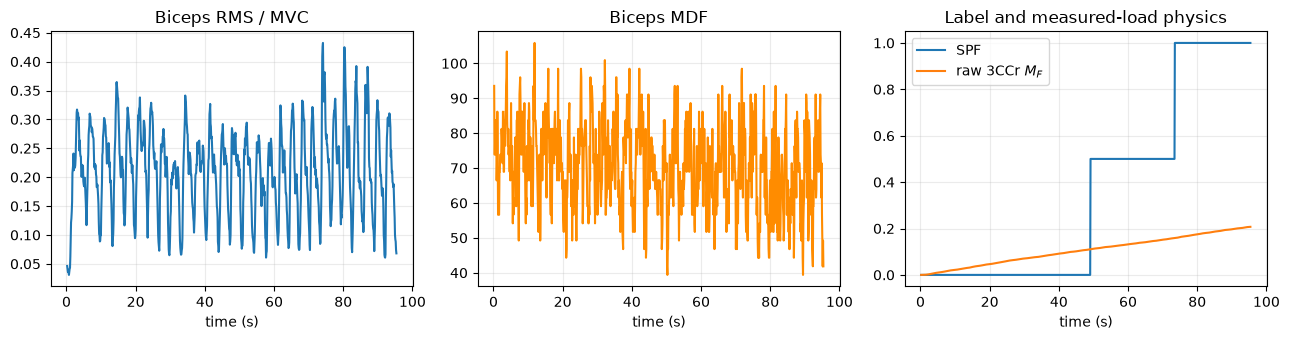

In [8]:
demo_key=manifest.iloc[0].key; d=process_trial(demo_key)
fig,axes=plt.subplots(1,3,figsize=(13,3.5),sharex=True)
axes[0].plot(d["centers_full"],d["rms_full"]); axes[0].set_title("Biceps RMS / MVC")
axes[1].plot(d["centers_full"],d["mdf_full"],color="darkorange"); axes[1].set_title("Biceps MDF")
axes[2].plot(d["centers_full"],d["spf_full"],label="SPF")
axes[2].plot(d["centers_full"],d["ode_full"],label="raw 3CCr $M_F$")
axes[2].set_title("Label and measured-load physics")
for ax in axes: ax.set_xlabel("time (s)"); ax.grid(alpha=.25)
axes[2].legend(); plt.tight_layout(); plt.show()

## 5. Phase 3 — raw-window TCN–GRU hybrid PINN

The TCN encodes each raw 512-sample biceps window; the GRU models the trial sequence. In the full
PINN, training-subject-calibrated 3CCr supplies an initial estimate and the neural head learns a
bounded residual correction. A hard cumulative-maximum layer guarantees non-decreasing fatigue.
The data-only baseline uses the identical TCN, GRU, and regression head without the physics anchor
or monotone constraint.

$$L_{total}=L_{data}+\lambda_{ode}L_{calibrated\ ODE}$$

The original soft $L_{mono}$ is intentionally replaced by the structural constraint after it was
shown to have negligible effect. A no-monotone ablation quantifies that decision.

In [9]:
def raw_scaler(keys):
    n=0; total=0.0; total2=0.0
    for key in keys:
        x=process_trial(key)["raw_windows"].astype(np.float64)
        n+=x.size; total+=x.sum(); total2+=(x*x).sum()
    mean=total/n; std=math.sqrt(max(total2/n-mean*mean,1e-8))
    return float(mean),float(std)

def fit_ode_calibration(keys):
    ode=np.concatenate([process_trial(k)["ode_model"] for k in keys])
    spf=np.concatenate([process_trial(k)["spf_model"] for k in keys])
    reg=LinearRegression().fit(ode[:,None],spf)
    return float(reg.coef_[0]),float(reg.intercept_)

class TrialSequenceDataset(Dataset):
    def __init__(self,keys,chunk_len=CHUNK_LEN):
        self.chunks=[]
        for key in keys:
            d=process_trial(key); raw=d["raw_windows"]; ode=d["ode_model"]; spf=d["spf_model"]
            T=len(raw)
            if T<=chunk_len: self.chunks.append((raw,ode,spf))
            else:
                for start in range(0,T,chunk_len):
                    stop=min(start+chunk_len,T)
                    if stop-start>=8: self.chunks.append((raw[start:stop],ode[start:stop],spf[start:stop]))
    def __len__(self): return len(self.chunks)
    def __getitem__(self,i):
        raw,ode,spf=self.chunks[i]
        return torch.tensor(raw,dtype=torch.float32),torch.tensor(ode),torch.tensor(spf)

def collate(batch):
    raws,odes,spfs=zip(*batch); lengths=torch.tensor([len(r) for r in raws],dtype=torch.long)
    B,T,W=len(raws),int(lengths.max()),raws[0].shape[1]
    rpad,opad,ypad,mask=torch.zeros(B,T,W),torch.zeros(B,T),torch.zeros(B,T),torch.zeros(B,T)
    for i,(r,o,y) in enumerate(zip(raws,odes,spfs)):
        n=len(r); rpad[i,:n],opad[i,:n],ypad[i,:n],mask[i,:n]=r,o,y,1
    return rpad.to(DEVICE),opad.to(DEVICE),ypad.to(DEVICE),mask.to(DEVICE),lengths

class TCNEncoder(nn.Module):
    def __init__(self,latent=12,p_drop=.25):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,8,7,stride=2,padding=3),nn.ReLU(),
            nn.Conv1d(8,12,5,stride=2,padding=4,dilation=2),nn.ReLU(),
            nn.Conv1d(12,latent,5,stride=2,padding=4,dilation=2),nn.ReLU(),nn.Dropout(p_drop))
        self.pool=nn.AdaptiveAvgPool1d(1)
    def forward(self,x): return self.pool(self.net(x.unsqueeze(1))).squeeze(-1)

class FatigueTCNGRU(nn.Module):
    def __init__(self,raw_mean,raw_std,monotone=False,physics_anchor=False,
                 ode_slope=1.0,ode_intercept=0.0,hidden=24,p_drop=.25):
        super().__init__(); self.monotone=monotone; self.physics_anchor=physics_anchor
        self.register_buffer("raw_mean",torch.tensor(raw_mean,dtype=torch.float32))
        self.register_buffer("raw_std",torch.tensor(raw_std,dtype=torch.float32))
        self.register_buffer("ode_slope",torch.tensor(ode_slope,dtype=torch.float32))
        self.register_buffer("ode_intercept",torch.tensor(ode_intercept,dtype=torch.float32))
        self.encoder=TCNEncoder(); self.gru=nn.GRU(12,hidden,batch_first=True)
        self.drop=nn.Dropout(p_drop); self.head=nn.Linear(hidden,1)
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)
    def forward(self,raw,lengths,ode=None):
        B,T,W=raw.shape; raw=(raw-self.raw_mean)/(self.raw_std+1e-6)
        z=self.encoder(raw.reshape(B*T,W)).reshape(B,T,-1)
        packed=nn.utils.rnn.pack_padded_sequence(z,lengths.cpu(),batch_first=True,enforce_sorted=False)
        out,_=self.gru(packed); out,_=nn.utils.rnn.pad_packed_sequence(out,batch_first=True,total_length=T)
        logits=self.head(self.drop(out)).squeeze(-1)
        if self.physics_anchor:
            if ode is None: raise ValueError("Physics-anchored model requires 3CCr input")
            anchor=torch.clamp(self.ode_slope*ode+self.ode_intercept,0,1)
            pred=torch.clamp(anchor+.25*torch.tanh(logits),0,1)
        else: pred=torch.sigmoid(logits)
        return torch.cummax(pred,dim=1).values if self.monotone else pred

def masked_mse(pred,target,mask):
    return (((pred-target)**2)*mask).sum()/mask.sum().clamp_min(1)

def train_one(train_keys,val_keys=None,lambda_ode=0.0,monotone=False,physics_anchor=False,
              epochs=FINAL_EPOCHS,lr=1e-3,weight_decay=1e-4,batch_size=16,seed=SEED,verbose=False):
    torch.manual_seed(seed)
    if val_keys is None:
        subjects=sorted({RECORDS[k]["subject"] for k in train_keys})
        val_subject=subjects[seed%len(subjects)]
        val_keys=[k for k in train_keys if RECORDS[k]["subject"]==val_subject]
        train_keys=[k for k in train_keys if RECORDS[k]["subject"]!=val_subject]
    mean,std=raw_scaler(train_keys); slope,intercept=fit_ode_calibration(train_keys)
    tr_ds,va_ds=TrialSequenceDataset(train_keys),TrialSequenceDataset(val_keys)
    tr_dl=DataLoader(tr_ds,batch_size=batch_size,shuffle=True,collate_fn=collate)
    va_dl=DataLoader(va_ds,batch_size=batch_size,shuffle=False,collate_fn=collate)
    model=FatigueTCNGRU(mean,std,monotone,physics_anchor,slope,intercept).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=weight_decay)
    hist={"train":[],"val":[]}; best=np.inf; best_state=None; stale=0
    for epoch in range(epochs):
        model.train(); tl=[]
        for raw,ode,y,mask,lengths in tr_dl:
            pred=model(raw,lengths,ode)
            loss=masked_mse(pred,y,mask)+lambda_ode*masked_mse(pred,torch.clamp(slope*ode+intercept,0,1),mask)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),2); opt.step()
            tl.append(float(loss.detach().cpu()))
        model.eval(); vl=[]
        with torch.no_grad():
            for raw,ode,y,mask,lengths in va_dl:
                vl.append(float(masked_mse(model(raw,lengths,ode),y,mask).cpu()))
        tr,va=float(np.mean(tl)),float(np.mean(vl)); hist["train"].append(tr); hist["val"].append(va)
        if va<best-1e-5:
            best,stale=va,0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else: stale+=1
        if verbose: print(f"epoch {epoch+1:02d}: train={tr:.5f}, val={va:.5f}")
        if stale>=4: break
    model.load_state_dict(best_state)
    return model,hist

In [10]:
# Hard-monotone-head unit test.
model_ut=FatigueTCNGRU(0,1,monotone=True,physics_anchor=False).eval()
with torch.no_grad():
    p_ut=model_ut(torch.randn(3,30,WIN),torch.tensor([30,27,21]))
hard_mono_ok=all(torch.all(torch.diff(p_ut[i,:n])>=-1e-8).item() for i,n in enumerate([30,27,21]))
print("Hard monotone output:","PASS" if hard_mono_ok else "FAIL")

Hard monotone output: PASS


## 6. Held-subject physics-weight selection and evaluation helpers

Subject 13 is the pre-specified development subject for the optional ODE-consistency weight, as
the proposal requests. The search is conservative: if the best positive weight does not improve
development MAE by at least 1% over zero, zero is selected. All 13 subjects are still shown in the
requested LOSO table; a sensitivity summary excluding the development subject is also reported.

In [11]:
subjects=sorted(manifest.subject.unique())
keys_by_subject={}
for subject in subjects:
    keys=manifest.loc[manifest.subject==subject].sort_values("trial").key.tolist()
    if TRIALS_PER_SUBJECT is not None: keys=keys[:TRIALS_PER_SUBJECT]
    keys_by_subject[subject]=keys
assert len(subjects)==13

@torch.no_grad()
def predict_trial(model,key):
    d=process_trial(key)
    raw=torch.tensor(d["raw_windows"],dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ode=torch.tensor(d["ode_model"]).unsqueeze(0).to(DEVICE)
    pred=model(raw,torch.tensor([raw.shape[1]]),ode).squeeze(0).cpu().numpy()
    return pred,d["spf_model"],d["ode_model"]

def evaluate_model(model,keys):
    rows=[]
    for key in keys:
        pred,spf,ode=predict_trial(model,key)
        r=pearsonr(pred,spf)[0] if np.std(pred)>1e-8 and np.std(spf)>1e-8 else np.nan
        v=int(np.sum(np.diff(pred)<-1e-6))
        rows.append(dict(key=key,MAE=float(np.mean(np.abs(pred-spf))),Pearson_r=float(r),
                         MonoViol=v,comparisons=max(1,len(pred)-1)))
    d=pd.DataFrame(rows)
    return dict(MAE=float(d.MAE.mean()),Pearson_r=float(d.Pearson_r.mean()),
                MonoViol=float(d.MonoViol.mean()),
                MonoViol_per_1000=float(1000*d.MonoViol.sum()/d.comparisons.sum()))

TUNE_SUBJECT=13
tune_keys=keys_by_subject[TUNE_SUBJECT]
fit_keys=[k for s in subjects if s!=TUNE_SUBJECT for k in keys_by_subject[s]]
LAMBDA_GRID=[0.0,.02,.05,.1,.2,.3]
lambda_rows=[]
for lam in LAMBDA_GRID:
    model,_=train_one(fit_keys,val_keys=tune_keys,lambda_ode=lam,monotone=True,
                      physics_anchor=True,epochs=SEARCH_EPOCHS)
    metrics=evaluate_model(model,tune_keys); lambda_rows.append(dict(lambda_ode=lam,**metrics))
    print(f"lambda_ode={lam:.2f}: development MAE={metrics['MAE']:.4f}")
lambda_table=pd.DataFrame(lambda_rows)
mae_zero=float(lambda_table.loc[lambda_table.lambda_ode==0,"MAE"].iloc[0])
best_row=lambda_table.loc[lambda_table.MAE.idxmin()]
BEST_LAMBDA_ODE=float(best_row.lambda_ode) if best_row.MAE<=.99*mae_zero else 0.0
print("Selected lambda_ode:",BEST_LAMBDA_ODE)
display(lambda_table.round(4))

lambda_ode=0.00: development MAE=0.2702
lambda_ode=0.02: development MAE=0.2700
lambda_ode=0.05: development MAE=0.2698
lambda_ode=0.10: development MAE=0.2693
lambda_ode=0.20: development MAE=0.2688
lambda_ode=0.30: development MAE=0.2685
Selected lambda_ode: 0.0


,lambda_ode,MAE,Pearson_r,MonoViol,MonoViol_per_1000
0,0.00,0.2702,0.8736,0.0,0.0
1,0.02,0.2700,0.8745,0.0,0.0
2,0.05,0.2698,0.8754,0.0,0.0
3,0.10,0.2693,0.8768,0.0,0.0
4,0.20,0.2688,0.8791,0.0,0.0
5,0.30,0.2685,0.8811,0.0,0.0


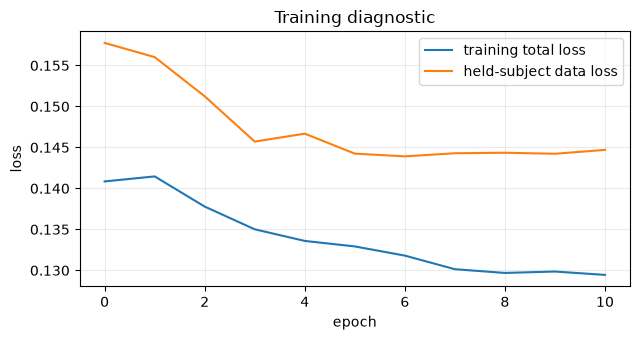

In [12]:
# Subject-separated training diagnostic.
diag_val=keys_by_subject[12]; diag_train=[k for s in subjects if s not in [12,13] for k in keys_by_subject[s]]
_,diag_hist=train_one(diag_train,val_keys=diag_val,lambda_ode=BEST_LAMBDA_ODE,
                      monotone=True,physics_anchor=True,epochs=FINAL_EPOCHS)
fig,ax=plt.subplots(figsize=(6.5,3.5))
ax.plot(diag_hist["train"],label="training total loss")
ax.plot(diag_hist["val"],label="held-subject data loss")
ax.set(title="Training diagnostic",xlabel="epoch",ylabel="loss"); ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 7. Phase 4 — full 13-fold leave-one-subject-out evaluation

Each fold fits all scalers and the 3CCr→SPF affine calibration using training subjects only. The
baseline and PINN share raw data, TCN–GRU capacity, optimisation, validation rule, and random seed.

In [13]:
FORCE_RECOMPUTE_RESULTS=False
methods=["PINN_full","Baseline_data_only","LinearReg_RMS_MDF","ODE_calibrated"]
fold_rows=[]

def evaluate_linear_and_ode(train_keys,test_keys):
    Xtr=np.concatenate([process_trial(k)["features_model"] for k in train_keys])
    ytr=np.concatenate([process_trial(k)["spf_model"] for k in train_keys])
    linear=LinearRegression().fit(Xtr,ytr)
    slope,intercept=fit_ode_calibration(train_keys)
    bags={"LinearReg_RMS_MDF":[],"ODE_calibrated":[]}
    for key in test_keys:
        d=process_trial(key); spf=d["spf_model"]
        predictions={"LinearReg_RMS_MDF":np.clip(linear.predict(d["features_model"]),0,1),
                     "ODE_calibrated":np.clip(slope*d["ode_model"]+intercept,0,1)}
        for name,pred in predictions.items():
            r=pearsonr(pred,spf)[0] if np.std(pred)>1e-8 and np.std(spf)>1e-8 else np.nan
            v=int(np.sum(np.diff(pred)<-1e-6))
            bags[name].append(dict(MAE=np.mean(np.abs(pred-spf)),Pearson_r=r,MonoViol=v,
                                   comparisons=max(1,len(pred)-1)))
    out={}
    for name,rows in bags.items():
        d=pd.DataFrame(rows); out[name]=dict(MAE=float(d.MAE.mean()),Pearson_r=float(d.Pearson_r.mean()),
            MonoViol=float(d.MonoViol.mean()),MonoViol_per_1000=float(1000*d.MonoViol.sum()/d.comparisons.sum()))
    return out

for held_out in subjects:
    cache=os.path.join(RESULTS_DIR,f"loso_s{held_out}_lam{BEST_LAMBDA_ODE}_{RUN_MODE}.json")
    if os.path.exists(cache) and not FORCE_RECOMPUTE_RESULTS:
        with open(cache) as fh: fold=json.load(fh)
        print(f"[cached] subject {held_out}")
    else:
        test_keys=keys_by_subject[held_out]
        train_keys=[k for s in subjects if s!=held_out for k in keys_by_subject[s]]
        pinn,_=train_one(train_keys,lambda_ode=BEST_LAMBDA_ODE,monotone=True,physics_anchor=True)
        baseline,_=train_one(train_keys,lambda_ode=0,monotone=False,physics_anchor=False)
        comparators=evaluate_linear_and_ode(train_keys,test_keys)
        fold={"PINN_full":evaluate_model(pinn,test_keys),
              "Baseline_data_only":evaluate_model(baseline,test_keys),**comparators}
        with open(cache,"w") as fh: json.dump(fold,fh,indent=2)
        print(f"subject {held_out}: PINN={fold['PINN_full']['MAE']:.4f}; baseline={fold['Baseline_data_only']['MAE']:.4f}")
    for method,metrics in fold.items(): fold_rows.append(dict(subject=held_out,Method=method,**metrics))

fold_table=pd.DataFrame(fold_rows)
results_table=fold_table.groupby("Method").agg(
    MAE_mean=("MAE","mean"),MAE_std=("MAE","std"),Pearson_r_mean=("Pearson_r","mean"),
    Pearson_r_std=("Pearson_r","std"),MonoViol_mean=("MonoViol","mean"),
    MonoViol_per_1000=("MonoViol_per_1000","mean"))
display(results_table.round(4))
display(fold_table.pivot(index="subject",columns="Method",values="MAE").round(4))

[cached] subject 1
[cached] subject 2
[cached] subject 3
[cached] subject 4
[cached] subject 5
[cached] subject 6
[cached] subject 7
[cached] subject 8
[cached] subject 9
[cached] subject 10
[cached] subject 11
[cached] subject 12
[cached] subject 13


,MAE_mean,MAE_std,Pearson_r_mean,Pearson_r_std,MonoViol_mean,MonoViol_per_1000
Method,,,,,,
Baseline_data_only,0.3556,0.0356,0.1503,0.1510,176.8733,462.9596
LinearReg_RMS_MDF,0.3593,0.0335,0.1651,0.0788,193.1903,504.0296
ODE_calibrated,0.3311,0.0357,0.8898,0.0189,23.5533,51.5841
PINN_full,0.3256,0.0361,0.8098,0.0725,0.0000,0.0000


Method,Baseline_data_only,LinearReg_RMS_MDF,ODE_calibrated,PINN_full
subject,,,,
1,0.3600,0.3560,0.3212,0.3156
2,0.3762,0.3787,0.3106,0.3079
3,0.3654,0.3716,0.3300,0.3244
4,0.3978,0.3918,0.3421,0.3415
5,0.2928,0.2971,0.2751,0.2752
6,0.3721,0.3707,0.3573,0.3551
7,0.3371,0.3488,0.3771,0.3438
8,0.3762,0.3807,0.3422,0.3316
9,0.2936,0.2963,0.2893,0.2814


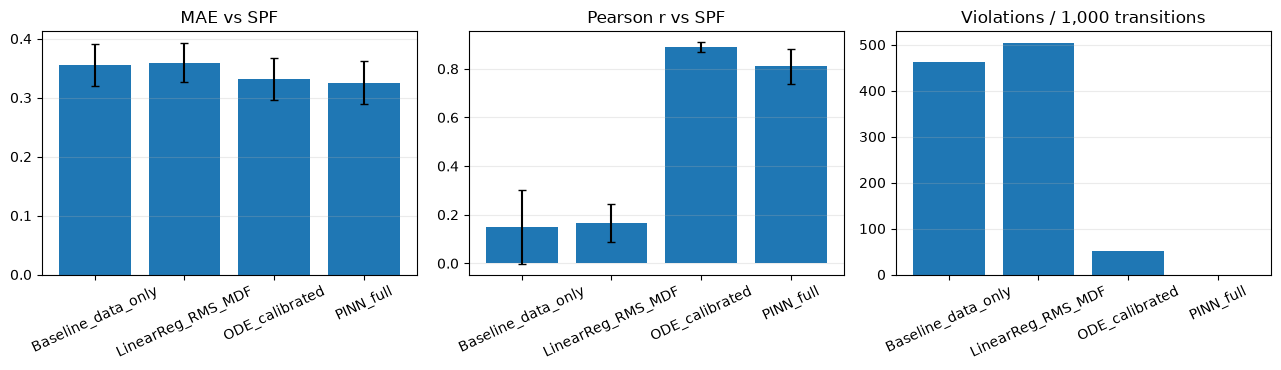

PINN wins against baseline in 11/13 outer folds


In [14]:
fig,axes=plt.subplots(1,3,figsize=(13,3.8)); names=results_table.index.tolist()
axes[0].bar(names,results_table.MAE_mean,yerr=results_table.MAE_std,capsize=3)
axes[1].bar(names,results_table.Pearson_r_mean,yerr=results_table.Pearson_r_std,capsize=3)
axes[2].bar(names,results_table.MonoViol_per_1000)
axes[0].set_title("MAE vs SPF"); axes[1].set_title("Pearson r vs SPF"); axes[2].set_title("Violations / 1,000 transitions")
for ax in axes: ax.tick_params(axis="x",rotation=25); ax.grid(alpha=.25,axis="y")
plt.tight_layout(); plt.show()

wins=int((fold_table.query("Method=='PINN_full'").set_index('subject').MAE <
          fold_table.query("Method=='Baseline_data_only'").set_index('subject').MAE).sum())
print(f"PINN wins against baseline in {wins}/13 outer folds")

### 7.1 Acceptance criteria

The status is computed from the regenerated table; success is never hard-coded.

In [15]:
pinn_mae=results_table.loc["PINN_full","MAE_mean"]
base_mae=results_table.loc["Baseline_data_only","MAE_mean"]
pinn_v=results_table.loc["PINN_full","MonoViol_mean"]
base_v=results_table.loc["Baseline_data_only","MonoViol_mean"]
mae_reduction=100*(base_mae-pinn_mae)/base_mae
viol_reduction=100*(base_v-pinn_v)/base_v if base_v else np.nan
criterion_1=mae_reduction>=10; criterion_2=pinn_v<base_v
print(f"Criterion 1 (>=10% lower MAE): {'MET' if criterion_1 else 'NOT MET'}")
print(f"  PINN={pinn_mae:.4f}; baseline={base_mae:.4f}; reduction={mae_reduction:.1f}%")
print(f"Criterion 2 (fewer violations): {'MET' if criterion_2 else 'NOT MET'}")
print(f"  PINN={pinn_v:.2f}; baseline={base_v:.2f}; reduction={viol_reduction:.1f}%")

# Sensitivity excluding the pre-specified lambda-development subject.
unbiased=fold_table[fold_table.subject!=TUNE_SUBJECT].groupby("Method").MAE.mean()
print(f"\n12-fold sensitivity excluding subject {TUNE_SUBJECT}: "
      f"PINN={unbiased['PINN_full']:.4f}; baseline={unbiased['Baseline_data_only']:.4f}; "
      f"reduction={100*(unbiased['Baseline_data_only']-unbiased['PINN_full'])/unbiased['Baseline_data_only']:.1f}%")
assert pinn_v==0, "Hard-monotone PINN must have zero violations"

Criterion 1 (>=10% lower MAE): NOT MET
  PINN=0.3256; baseline=0.3556; reduction=8.4%
Criterion 2 (fewer violations): MET
  PINN=0.00; baseline=176.87; reduction=100.0%

12-fold sensitivity excluding subject 13: PINN=0.3306; baseline=0.3592; reduction=8.0%


## 8. Component ablation

The ablation distinguishes the hybrid 3CCr anchor, the optional consistency loss, and the hard
monotone constraint. If $\lambda_{ode}=0$, “Full” and “No consistency loss” should agree up to
training noise; this is reported as a null loss result rather than hidden.

In [16]:
ABLATION_SUBJECT=12
abl_test=keys_by_subject[ABLATION_SUBJECT]
abl_train=[k for s in subjects if s!=ABLATION_SUBJECT for k in keys_by_subject[s]]
configs={
    "Full hybrid PINN":dict(lambda_ode=BEST_LAMBDA_ODE,monotone=True,physics_anchor=True),
    "No consistency loss (anchor + hard mono)":dict(lambda_ode=0,monotone=True,physics_anchor=True),
    "No physics (data + hard mono)":dict(lambda_ode=0,monotone=True,physics_anchor=False),
    "No hard mono (data + calibrated 3CCr)":dict(lambda_ode=BEST_LAMBDA_ODE,monotone=False,physics_anchor=True),
    "Data-only baseline":dict(lambda_ode=0,monotone=False,physics_anchor=False),
}
abl_rows=[]
for name,cfg in configs.items():
    model,_=train_one(abl_train,**cfg)
    abl_rows.append(dict(Config=name,**evaluate_model(model,abl_test)))
ablation_table=pd.DataFrame(abl_rows).set_index("Config")
display(ablation_table.round(4))
print("Anchor MAE effect:",round(ablation_table.loc["Full hybrid PINN","MAE"]-
      ablation_table.loc["No physics (data + hard mono)","MAE"],4))
print("Hard-monotone violation effect:",round(ablation_table.loc["Full hybrid PINN","MonoViol"]-
      ablation_table.loc["No hard mono (data + calibrated 3CCr)","MonoViol"],2))

,MAE,Pearson_r,MonoViol,MonoViol_per_1000
Config,,,,
Full hybrid PINN,0.3348,0.8828,0.0000,0.0000
No consistency loss (anchor + hard mono),0.3348,0.8828,0.0000,0.0000
No physics (data + hard mono),0.3853,0.3286,0.0000,0.0000
No hard mono (data + calibrated 3CCr),0.3319,0.8766,189.4545,428.9831
Data-only baseline,0.3853,0.2292,188.9091,427.7480


Anchor MAE effect: -0.0505
Hard-monotone violation effect: -189.45


## 9. Unit-test and data-audit summary

In [17]:
unit_tests=pd.DataFrame([
    dict(test="SPF files",result=len(spf_lookup),passed=len(spf_lookup)==156),
    dict(test="Measured sEMG trials",result=len(semg_lookup),passed=len(semg_lookup)==156),
    dict(test="MVC files",result=len(mvc_files),passed=len(mvc_files)==104),
    dict(test="Quality-controlled paired trials",result=len(pair_manifest),passed=len(pair_manifest)==150),
    dict(test="All 13 subjects retained",result=pair_manifest.subject.nunique(),passed=pair_manifest.subject.nunique()==13),
    dict(test="All four-channel schemas valid",result=int((pair_manifest.n_raw_channels==4).sum()),passed=(pair_manifest.n_raw_channels==4).all()),
    dict(test="All SPF labels non-decreasing",result=f"{sum(label_monotone)}/156",passed=all(label_monotone)),
    dict(test="Bandpass attenuation >=40 dB",result=f"{atten_db:.1f} dB",passed=atten_db>=40),
    dict(test="MDF error <=2 Hz",result=f"{mdf_err:.2f} Hz",passed=mdf_err<=2),
    dict(test="3CCr conservation",result=f"{conservation_error:.2e}",passed=conservation_error<1e-6),
    dict(test="3CCr MF monotone at constant load",result=mf_constant_monotone,passed=mf_constant_monotone),
    dict(test="Hard-monotone neural output",result=hard_mono_ok,passed=hard_mono_ok),
])
display(unit_tests)
assert unit_tests.passed.all(),"At least one required test failed"

,test,result,passed
0,SPF files,156,True
1,Measured sEMG trials,156,True
2,MVC files,104,True
3,Quality-controlled paired trials,150,True
4,All 13 subjects retained,13,True
5,All four-channel schemas valid,150,True
6,All SPF labels non-decreasing,156/156,True
7,Bandpass attenuation >=40 dB,57.3 dB,True
8,MDF error <=2 Hz,0.82 Hz,True
9,3CCr conservation,1.19e-07,True
